In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score

## Load Dataset

In [2]:
df=pd.read_csv('data/diabetes.csv')
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0
2,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0
3,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
4,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0


## Data Preprocessing

In [3]:
print("Missing values")
print(df.isnull().sum())
print("Duplicate values")
print(df.duplicated().sum())

Missing values
Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
Class     0
dtype: int64
Duplicate values
0


In [4]:
# Unique values in the Class column(Target)
df.Class.unique()

array([0, 1, 2])

In [5]:
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 65:
        return 'Adult'
    else:
        return 'Senior'
df['Age_Grp']=df['AGE'].apply(age_group)

#Encoding age group with numbers
df['Age_Grp'] = df['Age_Grp'].map({'Child': 0, 'Adult': 1, 'Senior': 2})
df.drop(columns=['AGE'], inplace=True)
df.head()

,Gender,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class,Age_Grp
0,0,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0,1
1,1,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0,1
2,1,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0,1
3,0,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0,1
4,0,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0,1


# EDA

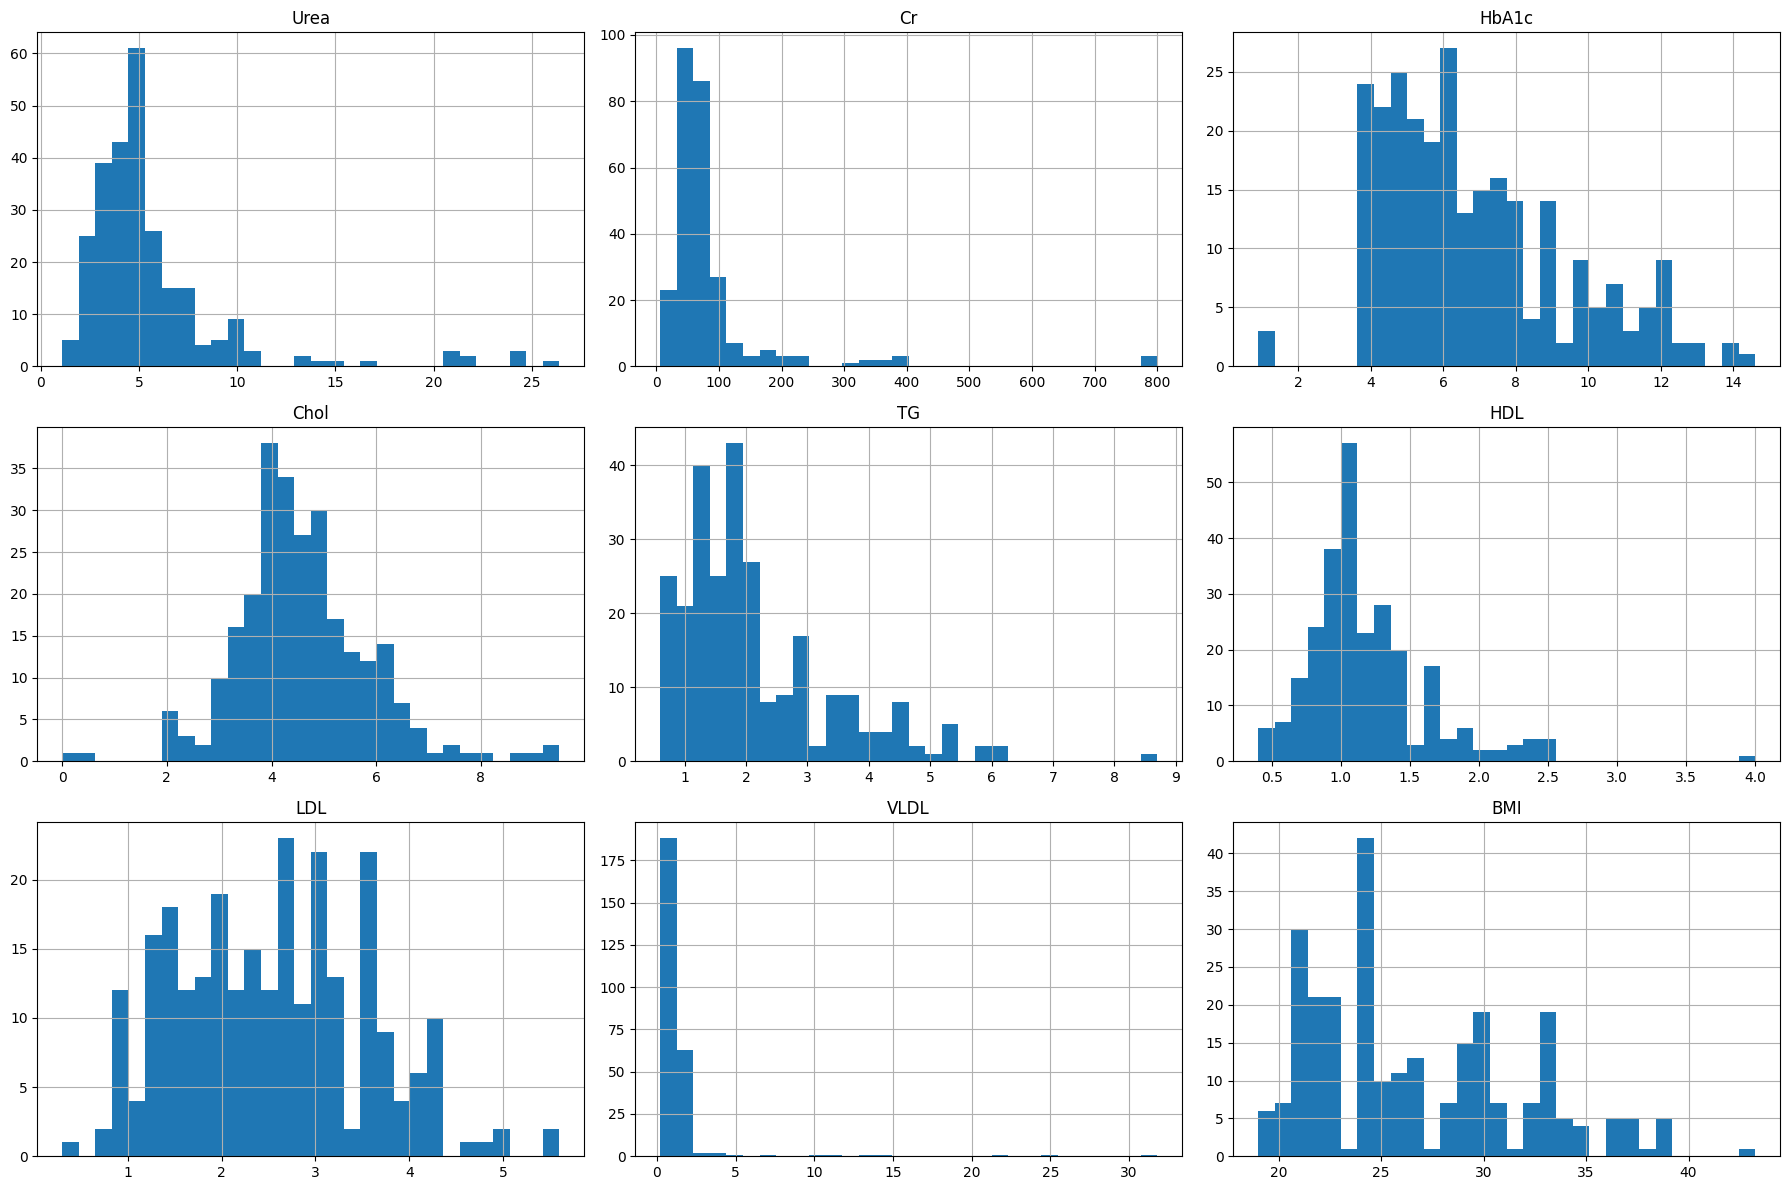

In [6]:
# List of columns to exclude from histogram
exclude_cols = ['Gender', 'Age_Grp', 'Class']

# Filter numeric columns except excluded ones
num_cols = df.select_dtypes(include='number').columns
num_cols = [col for col in num_cols if col not in exclude_cols]

# Plot histograms
df[num_cols].hist(bins=30, figsize=(18, 12))
plt.tight_layout()
plt.show()

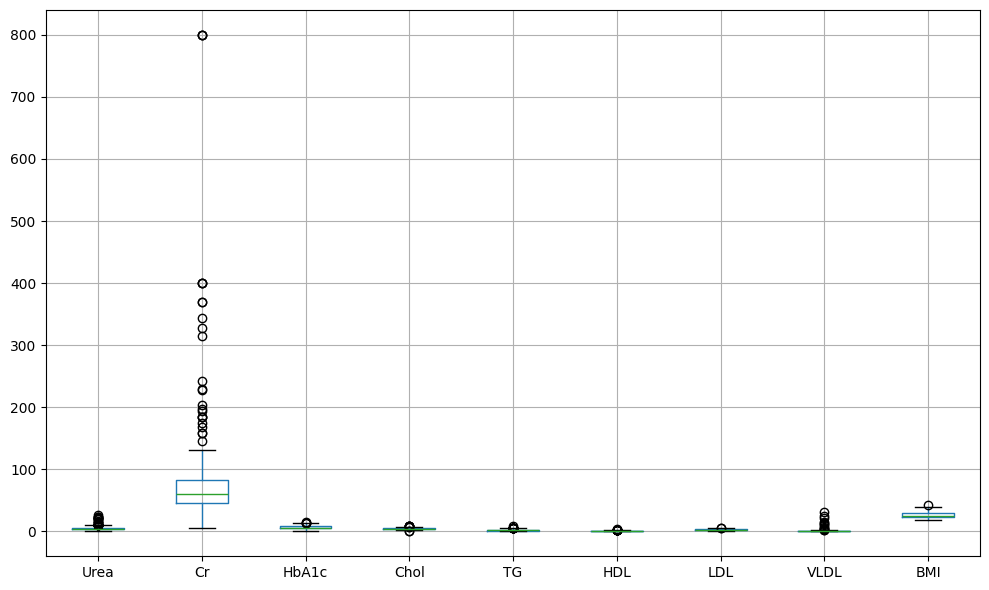

In [7]:
# Plot Boxplot
df[num_cols].boxplot(figsize=(10, 6))
plt.tight_layout()
plt.show()

In [8]:
# Cr has extreme outliers
df['Cr'].describe()

count    264.000000
mean      85.806818
std       99.400047
min        6.000000
25%       46.000000
50%       61.000000
75%       82.250000
max      800.000000
Name: Cr, dtype: float64

In [9]:
# Clip Cr values
upper = 200   # safe bound in µmol/L
df['Cr'] = df['Cr'].clip(upper=upper, lower=15)

In [10]:
x=df.drop(columns=['Class'])
y=df['Class']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

x_train_scale=x_train.drop(columns=['Gender','Age_Grp'])
x_test_scale=x_test.drop(columns=['Gender','Age_Grp'])
scaler=RobustScaler()
x_train_scale = scaler.fit_transform(x_train_scale)
x_test_scale = scaler.transform(x_test_scale)

x_train = np.concat([x_train_scale,x_train[['Gender','Age_Grp']]],axis=1)
x_test = np.concat([x_test_scale,x_test[['Gender','Age_Grp']]],axis=1)

# Train Model

In [11]:
# Decision Tree

dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

Accuracy Score: 0.9433962264150944
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.78      0.88      0.82         8
           2       0.96      0.93      0.94        27

    accuracy                           0.94        53
   macro avg       0.91      0.93      0.92        53
weighted avg       0.95      0.94      0.94        53



In [12]:
# Random Forest

rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

Accuracy Score: 0.9811320754716981
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.89      1.00      0.94         8
           2       1.00      0.96      0.98        27

    accuracy                           0.98        53
   macro avg       0.96      0.99      0.97        53
weighted avg       0.98      0.98      0.98        53



In [13]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb=GradientBoostingClassifier()
gb.fit(x_train,y_train)
y_pred=gb.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

Accuracy Score: 0.9622641509433962
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.80      1.00      0.89         8
           2       1.00      0.93      0.96        27

    accuracy                           0.96        53
   macro avg       0.93      0.98      0.95        53
weighted avg       0.97      0.96      0.96        53



In [14]:
# Extreme Gradient Boosting

from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

Accuracy Score: 0.9433962264150944
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       0.80      1.00      0.89         8
           2       1.00      0.89      0.94        27

    accuracy                           0.94        53
   macro avg       0.92      0.96      0.93        53
weighted avg       0.95      0.94      0.94        53



In [15]:
# LightGBM

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(x_train, y_train)
y_pred = lgbm.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 305
[LightGBM] [Info] Number of data points in the train set: 211, number of used features: 10
[LightGBM] [Info] Start training from score -0.995149
[LightGBM] [Info] Start training from score -1.886122
[LightGBM] [Info] Start training from score -0.736738
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

c:\Users\afzal\Jupyter Workspace\Week 58 (BW2)\Project\venv313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Model Selection
Based on the performance analysis, we decided to select Random forest classifier for prediction.


In [17]:
# Save Random Forest Model, label encoder and scaler

with open('models/diabetic_rf_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

with open('models/diabetic_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)


In [2]:
model=pickle.load(open('models/diabetic_rf_model.pkl','rb'))
scaler=pickle.load(open('models/diabetic_scaler.pkl','rb'))

def predict_diabetes(data_dict):
    df = pd.DataFrame([data_dict])

    # Columns in same order as training 
    num_cols = ['Urea','Cr','HbA1c','Chol','TG','HDL','LDL','VLDL','BMI']   # to be scaled
    cat_cols = ['Gender','Age_Grp']   # not scaled

    # Setting default values
    df['AGE']=df['AGE'].fillna(22)

    df['Gender'] = df['Gender'].fillna(0)

    # ---------- Check missing values for all other features ----------
    required_features = ['Urea','Cr','HbA1c','Chol','TG','HDL','LDL','VLDL','BMI']
    for col in required_features:
        if col not in df or pd.isna(df[col].values[0]):
            return "Data doesn't have enough details"

    # ---------- Create Age Group ----------
    def age_group(age):
        if age < 18:
            return 'Child'
        elif age < 65:
            return 'Adult'
        else:
            return 'Senior'

    df['Age_Grp'] = df['AGE'].apply(age_group)
    df.drop(columns=['AGE'], inplace=True)

    # ---------- Encode Age Group ----------
    df['Age_Grp'] = df['Age_Grp'].map({'Child': 0, 'Adult': 1, 'Senior': 2})

    # ---------- Clip Cr values ----------
    df['Cr'] = df['Cr'].clip(lower=15, upper=200)

    # ---------- Scale numerical ----------
    df_scaled_num = scaler.transform(df[num_cols])

    # ---------- Combine numerical + categorical ----------
    X = np.concatenate((df_scaled_num, df[cat_cols].values), axis=1)

    # ---------- Prediction ----------
    prediction = model.predict(X)[0]
    labels = {
        0: 'No Diabetes',
        1: 'Close to Diabetes',
        2: 'Diabetes'
    }

    return labels[prediction]


    


In [3]:
sample_input_mmol = {
    "Gender": 1,
    "AGE": 54,
    "Urea": 4.7,
    "Cr": 46,
    "HbA1c": 4.9,
    "Chol": 4.2,
    "TG": 0.9,
    "HDL": 2.4,
    "LDL": 1.4,
    "VLDL": 0.5,
    "BMI": 24
}

result=predict_diabetes(sample_input_mmol)
print(result)

No Diabetes


In [4]:
from diabetics_llm_extractor import LabReportExtractor
from my_secrets import api_key

report_extractor = LabReportExtractor(api_key)

lab_text = """
Patient: Male, age 54.
Urea: 28 mg/dL
Creatinine: 1.2 mg/dL   
HbA1c: 6.7%
Cholesterol: 190 mg/dL
Triglycerides: 140 mg/dL
HDL: 50 mg/dL
LDL: 110 mg/dL
VLDL: 20 mg/dL
BMI: 24.5 kg/m2
"""

data = report_extractor.extract(lab_text)
print(data)


{'Gender': 1, 'AGE': 54, 'Urea': 4.662, 'Cr': 106.08, 'HbA1c': 6.7, 'Chol': 4.911, 'TG': 1.582, 'HDL': 1.295, 'LDL': 2.849, 'VLDL': 0.518, 'BMI': 24.5}


In [5]:
predict_diabetes(data)

'Close to Diabetes'